<a href="https://colab.research.google.com/github/majd-almohsen/multi-task-eye-disease-detection-vit/blob/main/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# أولاً: تنظيف شامل
import os, shutil, gc, torch

# أغلاق أي توصيل سابق
try:
    from google.colab import drive
    drive.flush_and_unmount()
except:
    pass

# تنظيف الذاكرة
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# الآن وصّل Drive
print("جارٍ توصيل Google Drive...")
drive.mount('/content/drive', force_remount=True)
print("تم التوصيل بنجاح!")

جارٍ توصيل Google Drive...
Mounted at /content/drive
تم التوصيل بنجاح!


✅ تم حفظ الصورة في: /content/before_after_comparison.png


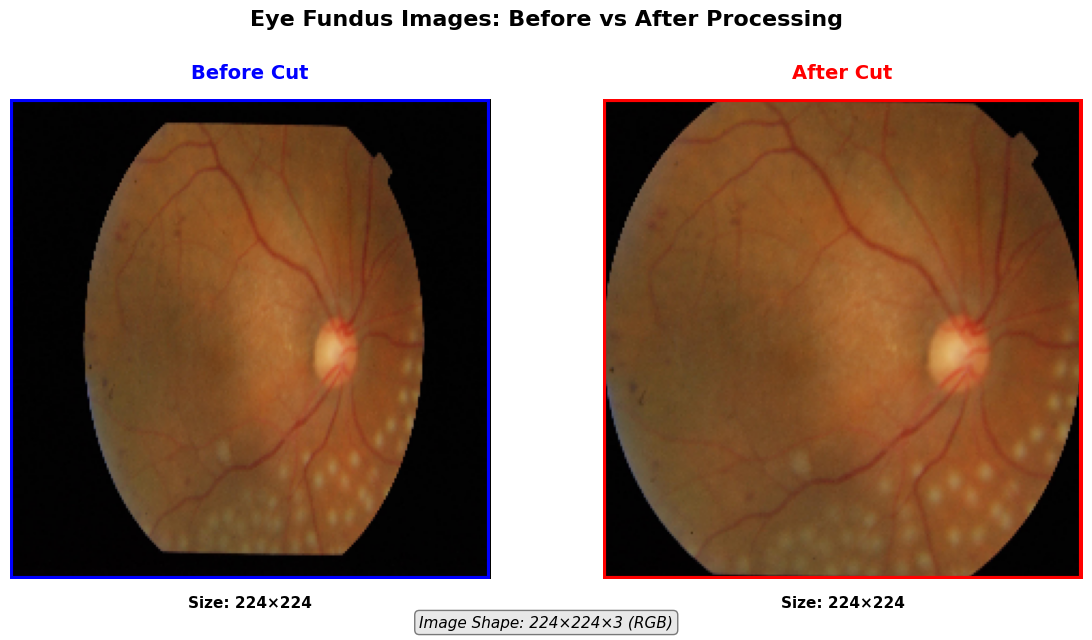

📊 معلومات الصور:
  الصورة الأولى (Before):
    - المسار: /content/sample_data/aaaaaa/875a2fc5fe23.jpg
    - الشكل: (224, 224, 3)
    - نوع البيانات: uint8
    - نطاق القيم: 0 إلى 227

  الصورة الثانية (After):
    - المسار: /content/sample_data/aaaaaa_cropped/875a2fc5fe23.jpg
    - الشكل: (224, 224, 3)
    - نوع البيانات: uint8
    - نطاق القيم: 0 إلى 227


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# مسارات الصور (عدلها حسب مساراتك)
before_path = '/content/sample_data/aaaaaa/875a2fc5fe23.jpg'  # قبل القص
after_path = '/content/sample_data/aaaaaa_cropped/875a2fc5fe23.jpg'    # بعد القص

# تحميل الصور الملونة
before_image = cv2.imread(before_path)
after_image = cv2.imread(after_path)

# تحويل من BGR (OpenCV) إلى RGB (Matplotlib)
before_image_rgb = cv2.cvtColor(before_image, cv2.COLOR_BGR2RGB)
after_image_rgb = cv2.cvtColor(after_image, cv2.COLOR_BGR2RGB)

# تغيير الحجم إلى 224x224 (إذا لم تكن بالفعل)
if before_image_rgb.shape[:2] != (224, 224):
    before_image_rgb = cv2.resize(before_image_rgb, (224, 224))
if after_image_rgb.shape[:2] != (224, 224):
    after_image_rgb = cv2.resize(after_image_rgb, (224, 224))

# إنشاء الشكل
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=100)

# الصورة قبل القص
axes[0].imshow(before_image_rgb)
axes[0].set_title('Before Cut', fontsize=14, fontweight='bold', pad=15, color='blue')
axes[0].text(0.5, -0.05, f'Size: {before_image_rgb.shape[1]}×{before_image_rgb.shape[0]}',
             ha='center', va='center', transform=axes[0].transAxes,
             fontsize=11, fontweight='bold')
axes[0].axis('off')

# إضافة مربع حول الصورة
rect = Rectangle((0, 0), 223, 223, linewidth=3, edgecolor='blue', facecolor='none')
axes[0].add_patch(rect)

# الصورة بعد القص
axes[1].imshow(after_image_rgb)
axes[1].set_title('After Cut', fontsize=14, fontweight='bold', pad=15, color='red')
axes[1].text(0.5, -0.05, f'Size: {after_image_rgb.shape[1]}×{after_image_rgb.shape[0]}',
             ha='center', va='center', transform=axes[1].transAxes,
             fontsize=11, fontweight='bold')
axes[1].axis('off')

# إضافة مربع حول الصورة
rect = Rectangle((0, 0), 223, 223, linewidth=3, edgecolor='red', facecolor='none')
axes[1].add_patch(rect)

# إضافة عنوان رئيسي
plt.suptitle('Eye Fundus Images: Before vs After Processing',
             fontsize=16, fontweight='bold', y=1.05)

# ضبط المسافات
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.1)

# معلومات إضافية أسفل الصور
fig.text(0.5, 0.02,
         f'Image Shape: {before_image_rgb.shape[1]}×{before_image_rgb.shape[0]}×{before_image_rgb.shape[2]} (RGB)',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.5))

# حفظ الصورة المعروضة
output_path = '/content/before_after_comparison.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ تم حفظ الصورة في: {output_path}")

plt.show()

# طباعة معلومات تقنية
print("📊 معلومات الصور:")
print(f"  الصورة الأولى (Before):")
print(f"    - المسار: {before_path}")
print(f"    - الشكل: {before_image_rgb.shape}")
print(f"    - نوع البيانات: {before_image_rgb.dtype}")
print(f"    - نطاق القيم: {before_image_rgb.min()} إلى {before_image_rgb.max()}")

print(f"\n  الصورة الثانية (After):")
print(f"    - المسار: {after_path}")
print(f"    - الشكل: {after_image_rgb.shape}")
print(f"    - نوع البيانات: {after_image_rgb.dtype}")
print(f"    - نطاق القيم: {after_image_rgb.min()} إلى {after_image_rgb.max()}")

✅ Loaded: 218c822a3dd9.jpg - Shape: (224, 224, 3)
✅ Loaded: 1060_left.jpg - Shape: (224, 224, 3)
✅ Loaded: 218c822a3dd9.jpg - Shape: (224, 224, 3)
✅ Loaded: 1060_left.jpg - Shape: (224, 224, 3)

💾 Saved to: /content/color_unification_comparison.png


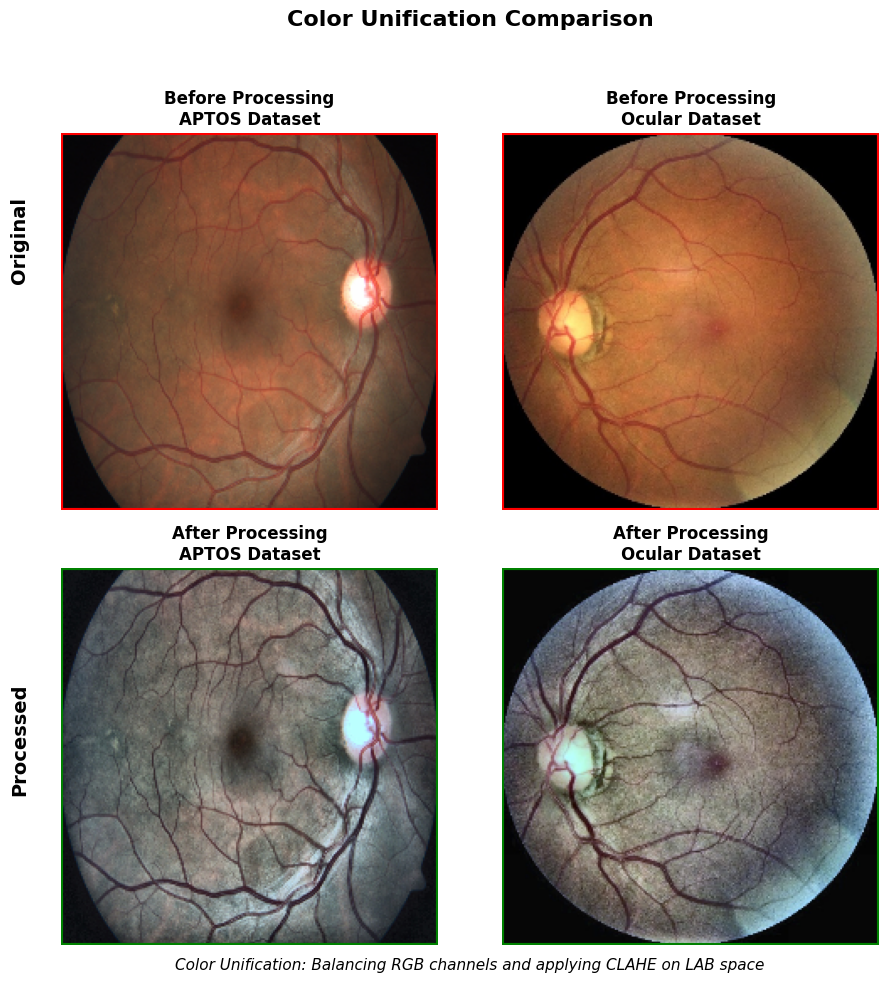


📊 Color Statistics (RGB Mean Values):
------------------------------------------------------------
Image                     Red        Green      Blue       Note
------------------------------------------------------------
Before - APTOS            107.3      70.5       52.0       Needs correction
Before - Ocular           120.4      74.9       45.3       Needs correction
After - APTOS             96.0       96.0       95.4       ✓ Balanced
After - Ocular            91.6       91.8       91.8       ✓ Balanced


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ========== المسارات - عدلها هنا ==========
paths = [
    '/content/drive/MyDrive/your_folder/before_APTOS.jpg',    # الصورة 1 قبل
    '/content/drive/MyDrive/your_folder/before_Ocular.jpg',   # الصورة 2 قبل
    '/content/drive/MyDrive/your_folder/after_APTOS.jpg',     # الصورة 1 بعد
    '/content/drive/MyDrive/your_folder/after_Ocular.jpg'     # الصورة 2 بعد
]

# ========== تحميل الصور ==========
images = []
for i, path in enumerate(paths):
    img = cv2.imread(path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (224, 224))
        images.append(img_rgb)
        print(f"✅ Loaded: {path.split('/')[-1]} - Shape: {img_rgb.shape}")
    else:
        print(f"❌ Error loading: {path}")
        images.append(np.zeros((224, 224, 3), dtype=np.uint8))

# ========== إنشاء الشكل ==========
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Color Unification Comparison', fontsize=16, fontweight='bold')

# ========== وضع الصور في المخطط 2×2 ==========
# الصف الأول: قبل المعالجة
axes[0, 0].imshow(images[0])
axes[0, 0].set_title('Before Processing\nAPTOS Dataset', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(images[1])
axes[0, 1].set_title('Before Processing\nOcular Dataset', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# الصف الثاني: بعد المعالجة
axes[1, 0].imshow(images[2])
axes[1, 0].set_title('After Processing\nAPTOS Dataset', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(images[3])
axes[1, 1].set_title('After Processing\nOcular Dataset', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

# ========== إضافة تسميات جانبية ==========
fig.text(0.04, 0.75, 'Original', fontsize=14, fontweight='bold', rotation=90, va='center')
fig.text(0.04, 0.25, 'Processed', fontsize=14, fontweight='bold', rotation=90, va='center')

# ========== إضافة حدود ==========
for i in range(2):
    for j in range(2):
        color = 'red' if i == 0 else 'green'
        border = plt.Rectangle((0, 0), 1, 1, transform=axes[i, j].transAxes,
                              fill=False, edgecolor=color, linewidth=3)
        axes[i, j].add_patch(border)

# ========== معلومات الألوان ==========
fig.text(0.5, 0.02,
         'Color Unification: Balancing RGB channels and applying CLAHE on LAB space',
         ha='center', fontsize=11, style='italic')

plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.95])

# ========== حفظ النتيجة ==========
output_path = '/content/drive/MyDrive/processing_Zain/color_unification_comparison.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n💾 Saved to: {output_path}")

plt.show()

# ========== إحصائيات الألوان ==========
print("\n📊 Color Statistics (RGB Mean Values):")
print("-" * 60)
print(f"{'Image':<25} {'Red':<10} {'Green':<10} {'Blue':<10} {'Note'}")
print("-" * 60)

for i, img in enumerate(images):
    mean_r = img[:,:,0].mean()
    mean_g = img[:,:,1].mean()
    mean_b = img[:,:,2].mean()

    title = ['Before - APTOS', 'Before - Ocular', 'After - APTOS', 'After - Ocular'][i]

    # حساب توازن الألوان
    balance_score = abs(mean_r - mean_g) + abs(mean_g - mean_b) + abs(mean_b - mean_r)
    note = "✓ Balanced" if balance_score < 40 else "Needs correction"

    print(f"{title:<25} {mean_r:<10.1f} {mean_g:<10.1f} {mean_b:<10.1f} {note}")

In [ ]:
from PIL import Image
import os
import sys

def remove_borders_simple(input_path, output_path):
    """إزالة الحواف السوداء - نسخة مبسطة"""
    try:
        img = Image.open(input_path).convert('RGB')
        width, height = img.size
        pixels = img.load()

        # إيجاد المحتوى غير الأسود
        left, right, top, bottom = width, 0, height, 0

        for y in range(height):
            for x in range(width):
                r, g, b = pixels[x, y]
                if r > 30 or g > 30 or b > 30:  # إذا لم يكن أسوداً داكن
                    left = min(left, x)
                    right = max(right, x)
                    top = min(top, y)
                    bottom = max(bottom, y)

        if left < right and top < bottom:
            img.crop((left, top, right+1, bottom+1)).save(output_path, 'JPEG', quality=95)
            print(f"تم قص {os.path.basename(input_path)}")
        else:
            img.save(output_path, 'JPEG', quality=95)

    except Exception as e:
        print(f"خطأ: {os.path.basename(input_path)} - {e}")
        import shutil
        shutil.copy(input_path, output_path)

# معالجة جميع الملفات في مجلد
input_dir = "/content/sample_data/aaaaaa"
output_dir = input_dir + "_cropped"

os.makedirs(output_dir, exist_ok=True)

for filename in os.listdir(input_dir):
    if filename.lower().endswith(('.jpg', '.jpeg')):
        input_file = os.path.join(input_dir, filename)
        output_file = os.path.join(output_dir, filename)
        remove_borders_simple(input_file, output_file)

print("تم الانتهاء!")


تم قص 875a2fc5fe23.jpg
تم الانتهاء!


In [ ]:
import os

# حدد مسار المجلد
folder_path = '/content/drive/MyDrive/Data_Zain/diabetes/severe_cropped'  # غير هذا المسار لمجلدك

# عد جميع الملفات في المجلد
all_files = os.listdir(folder_path)

# عد فقط الملفات ذات الامتدادات الشائعة للصور
image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff')
image_files = [f for f in all_files if f.lower().endswith(image_extensions)]

print(f'عدد الصور في المجلد: {len(image_files)}')

عدد الصور في المجلد: 653


In [ ]:
import shutil
folder_path = ''
shutil.rmtree(folder_path)

In [ ]:
import cv2
import os
import numpy as np
from tqdm import tqdm

def enhance_all_images_uniform(input_folder, output_folder):
    """
    نفس المعالجة لكل الصور بغض النظر عن الفئة
    """
    if not os.path.exists(input_folder):
        print(f"⚠️ المجلد غير موجود: {input_folder}")
        return 0

    os.makedirs(output_folder, exist_ok=True)
    processed = 0

    for filename in tqdm(os.listdir(input_folder)):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.jfif')):
            img_path = os.path.join(input_folder, filename)

            try:
                # 1. قراءة الصورة
                img = cv2.imread(img_path)
                if img is None:
                    continue

                # 2. تصحيح توازن الألوان (الخطوة الأساسية)
                img_float = img.astype(np.float32) / 255.0
                mean_r = np.mean(img_float[:,:,0])
                mean_g = np.mean(img_float[:,:,1])
                mean_b = np.mean(img_float[:,:,2])
                gray_mean = (mean_r + mean_g + mean_b) / 3.0

                r_gain = gray_mean / (mean_r + 1e-7)
                g_gain = gray_mean / (mean_g + 1e-7)
                b_gain = gray_mean / (mean_b + 1e-7)

                img_corrected = img_float.copy()
                img_corrected[:,:,0] = np.clip(img_corrected[:,:,0] * r_gain, 0, 1)
                img_corrected[:,:,1] = np.clip(img_corrected[:,:,1] * g_gain, 0, 1)
                img_corrected[:,:,2] = np.clip(img_corrected[:,:,2] * b_gain, 0, 1)
                img_corrected = (img_corrected * 255).astype(np.uint8)

                # 3. تحويل إلى LAB وتطبيق CLAHE
                img_rgb = cv2.cvtColor(img_corrected, cv2.COLOR_BGR2RGB)
                lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
                l, a, b = cv2.split(lab)

                # 4. CLAHE موحد لكل الصور
                clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
                l_enhanced = clahe.apply(l)

                # 5. الدمج والعودة إلى BGR
                enhanced_lab = cv2.merge((l_enhanced, a, b))
                enhanced_rgb = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
                enhanced_bgr = cv2.cvtColor(enhanced_rgb, cv2.COLOR_RGB2BGR)

                # 6. الحفظ
                output_path = os.path.join(output_folder, filename)
                cv2.imwrite(output_path, enhanced_bgr)
                processed += 1

            except Exception as e:
                print(f"❌ خطأ في {filename}: {str(e)[:50]}")

    return processed

# ========== المسارات ==========
base_path = '/content/drive/MyDrive/Data_Zain'
enhanced_path = '/content/Data_Zain_Enhanced_Uniform'

# ========== معالجة جميع المجلدات ==========
folders_to_process = [
    # Normal
    (f'{base_path}/Normal/Normal_APTOS', f'{enhanced_path}/Normal/Normal_APTOS'),
    (f'{base_path}/Normal/Normal_Ocular', f'{enhanced_path}/Normal/Normal_Ocular'),

    # Diabetes
    (f'{base_path}/diabetes/mild_moderate', f'{enhanced_path}/diabetes/mild_moderate'),
    (f'{base_path}/diabetes/severe', f'{enhanced_path}/diabetes/severe'),

    # Others
    (f'{base_path}/Others', f'{enhanced_path}/Others')
]

total_processed = 0
for input_folder, output_folder in folders_to_process:
    print(f"\n🔧 معالجة: {input_folder}")
    processed = enhance_all_images_uniform(input_folder, output_folder)
    total_processed += processed
    print(f"   ✅ تمت: {processed} صورة")

print(f"\n🎉 اكتملت المعالجة الموحدة!")
print(f"📊 الإجمالي: {total_processed} صورة")
print(f"📁 المسار الجديد: {enhanced_path}")

# ========== عرض عينة ==========
print("\n🔍 عرض عينة من الصور المحسنة:")
sample_folder = f'{enhanced_path}/Normal/Normal_APTOS'
if os.path.exists(sample_folder):
    sample_files = [f for f in os.listdir(sample_folder) if f.lower().endswith(('.jpg', '.png'))][:3]
    for f in sample_files:
        print(f"   📄 {f}")


🔧 معالجة: /content/drive/MyDrive/Data_Zain/Normal/Normal_APTOS


  0%|          | 1/612 [00:00<08:43,  1.17it/s]

In [ ]:
import tensorflow as tf
import os
import numpy as np
import json
from pathlib import Path

print("🚀 بدء معالجة البيانات وحفظها كـ TFRecord...")

# ========== 1. إعدادات المسارات ==========
base_path = '/content/Data_Zain_Enhanced_Uniform'

normal_paths = [
    '/content/Data_Zain_Enhanced_Uniform/Normal/Normal_APTOS',
    '/content/Data_Zain_Enhanced_Uniform/Normal/Normal_Ocular'
]

diabetes_paths = [
    '/content/Data_Zain_Enhanced_Uniform/diabetes/mild_moderate',
    '/content/Data_Zain_Enhanced_Uniform/diabetes/severe'
]

others_path = '/content/Data_Zain_Enhanced_Uniform/Others'

# مسار لحفظ TFRecord
tfrecord_path = '/content/drive/MyDrive/Data_Zain/Processed_Binary_Data_ViT'
os.makedirs(tfrecord_path, exist_ok=True)

# ========== 2. دالة تحميل الصور (بالصيغة التي يتوقعها ViT) ==========
def load_and_preprocess_image_vit(file_path, label):
    """تحميل صورة ومعالجتها لتناسب ViT"""
    # 1. قراءة الصورة
    img = tf.io.read_file(file_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)

    # 2. تغيير الحجم إلى 224×224 (مطلوب لـ ViT)
    img = tf.image.resize(img, [224, 224])

    # 3. تطبيع ViT (الطريقة القياسية التي يستخدمها HuggingFace)
    # ViT يتوقع قيم من 0 إلى 1
    img = tf.cast(img, tf.float32) / 255.0

    # 4. التسمية
    label = tf.cast(label, tf.int32)

    return img, label

# ========== 3. دالة إنشاء TFRecord (مبسطة) ==========
def create_tfrecord_example_simple(image_path, label):
    """إنشاء مثال TFRecord بشكل مبسط"""
    # تحميل الصورة
    image, label = load_and_preprocess_image_vit(image_path, label)

    # تحويل الصورة إلى bytes
    image_bytes = tf.io.serialize_tensor(image).numpy()

    # إنشاء المثال
    feature = {
        'image': tf.train.Feature(
            bytes_list=tf.train.BytesList(value=[image_bytes])
        ),
        'label': tf.train.Feature(
            int64_list=tf.train.Int64List(value=[label])
        ),
        'image_path': tf.train.Feature(
            bytes_list=tf.train.BytesList(value=[image_path.encode('utf-8')])
        )
    }

    return tf.train.Example(features=tf.train.Features(feature=feature))

# ========== 4. جمع كل مسارات الصور ==========
print("\n🔍 جمع مسارات الصور...")

all_images = []
stats = {'Normal': 0, 'Diabetes': 0, 'Others': 0, 'Total': 0}

# جمع صور Normal
for folder in normal_paths:
    if os.path.exists(folder):
        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        all_images.extend([(img, 0) for img in images])  # 0 لـ Normal
        stats['Normal'] += len(images)
        print(f"  ✓ {Path(folder).name}: {len(images)} صورة (Normal)")

# جمع صور Diabetes
for folder in diabetes_paths:
    if os.path.exists(folder):
        images = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        all_images.extend([(img, 1) for img in images])  # 1 لـ Sick
        stats['Diabetes'] += len(images)
        print(f"  ✓ {Path(folder).name}: {len(images)} صورة (Sick)")

# جمع صور Others
if os.path.exists(others_path):
    images = [os.path.join(others_path, f) for f in os.listdir(others_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    all_images.extend([(img, 1) for img in images])  # 1 لـ Sick
    stats['Others'] += len(images)
    print(f"  ✓ {Path(others_path).name}: {len(images)} صورة (Sick)")

stats['Total'] = len(all_images)
stats['Sick'] = stats['Diabetes'] + stats['Others']

print(f"\n📊 الإجمالي: {stats['Total']} صورة")
print(f"  - Normal: {stats['Normal']}")
print(f"  - Sick (Diabetes+Others): {stats['Sick']}")

# حفظ الإحصائيات
with open(f'{tfrecord_path}/dataset_stats.json', 'w') as f:
    json.dump(stats, f, indent=4)

# ========== 5. خلط وتقسيم البيانات ==========
print("\n🔄 خلط وتقسيم البيانات...")
np.random.shuffle(all_images)

split_idx = int(len(all_images) * 0.8)
train_images = all_images[:split_idx]
test_images = all_images[split_idx:]

print(f"  - التدريب: {len(train_images)} صورة ({100*len(train_images)/len(all_images):.1f}%)")
print(f"  - الاختبار: {len(test_images)} صورة ({100*len(test_images)/len(all_images):.1f}%)")

# ========== 6. حفظ بيانات التدريب ==========
print("\n💾 حفظ بيانات التدريب كـ TFRecord...")
train_tfrecord_path = f'{tfrecord_path}/train.tfrecord'

with tf.io.TFRecordWriter(train_tfrecord_path) as writer:
    for i, (img_path, label) in enumerate(train_images):
        try:
            example = create_tfrecord_example_simple(img_path, label)
            writer.write(example.SerializeToString())

            if (i + 1) % 100 == 0:
                print(f"  ✓ تم حفظ {i + 1}/{len(train_images)} صورة")
        except Exception as e:
            print(f"  ⚠️ خطأ في {img_path}: {e}")

print(f"✅ تم حفظ بيانات التدريب: {train_tfrecord_path}")

# ========== 7. حفظ بيانات الاختبار ==========
print("\n💾 حفظ بيانات الاختبار كـ TFRecord...")
test_tfrecord_path = f'{tfrecord_path}/test.tfrecord'

with tf.io.TFRecordWriter(test_tfrecord_path) as writer:
    for i, (img_path, label) in enumerate(test_images):
        try:
            example = create_tfrecord_example_simple(img_path, label)
            writer.write(example.SerializeToString())

            if (i + 1) % 100 == 0:
                print(f"  ✓ تم حفظ {i + 1}/{len(test_images)} صورة")
        except Exception as e:
            print(f"  ⚠️ خطأ في {img_path}: {e}")

print(f"✅ تم حفظ بيانات الاختبار: {test_tfrecord_path}")

# ========== 8. حفظ معلومات التقسيم ==========
split_info = {
    'train_count': len(train_images),
    'test_count': len(test_images),
    'total_count': len(all_images),
    'train_ratio': len(train_images) / len(all_images),
    'test_ratio': len(test_images) / len(all_images),
    'tfrecord_paths': {
        'train': train_tfrecord_path,
        'test': test_tfrecord_path
    }
}

with open(f'{tfrecord_path}/split_info.json', 'w') as f:
    json.dump(split_info, f, indent=4)

# ========== 9. دالة تحميل TFRecord (مبسطة) ==========
print("\n🧪 اختبار قراءة TFRecord...")

def parse_tfrecord_vit(example_proto):
    """تحليل مثال TFRecord لتناسب ViT"""
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64),
        'image_path': tf.io.FixedLenFeature([], tf.string)
    }

    parsed = tf.io.parse_single_example(example_proto, feature_description)

    # استعادة الصورة
    image = tf.io.parse_tensor(parsed['image'], out_type=tf.float32)

    # التأكد من الشكل (224, 224, 3)
    image = tf.ensure_shape(image, [224, 224, 3])

    # استعادة التسمية
    label = tf.cast(parsed['label'], tf.float32)

    return image, label

# اختبار سريع
test_dataset = tf.data.TFRecordDataset([test_tfrecord_path])
test_dataset = test_dataset.map(parse_tfrecord_vit)
test_dataset = test_dataset.batch(4).take(1)

for images, labels in test_dataset:
    print(f"\n✅ اختبار ناجح!")
    print(f"  - شكل الصور: {images.shape}")  # (4, 224, 224, 3)
    print(f"  - شكل التسميات: {labels.shape}")  # (4,)
    print(f"  - نطاق البكسل: [{tf.reduce_min(images):.3f}, {tf.reduce_max(images):.3f}]")
    print(f"  - أمثلة تسميات: {labels.numpy()}")

print(f"\n🎉 تم إنشاء البيانات بنجاح في: {tfrecord_path}")

🚀 بدء معالجة البيانات وحفظها كـ TFRecord...

🔍 جمع مسارات الصور...
  ✓ Normal_APTOS: 612 صورة (Normal)
  ✓ Normal_Ocular: 2000 صورة (Normal)
  ✓ mild_moderate: 653 صورة (Sick)
  ✓ severe: 653 صورة (Sick)
  ✓ Others: 1306 صورة (Sick)

📊 الإجمالي: 5224 صورة
  - Normal: 2612
  - Sick (Diabetes+Others): 2612

🔄 خلط وتقسيم البيانات...
  - التدريب: 4179 صورة (80.0%)
  - الاختبار: 1045 صورة (20.0%)

💾 حفظ بيانات التدريب كـ TFRecord...
  ✓ تم حفظ 100/4179 صورة
  ✓ تم حفظ 200/4179 صورة
  ✓ تم حفظ 300/4179 صورة
  ✓ تم حفظ 400/4179 صورة
  ✓ تم حفظ 500/4179 صورة
  ✓ تم حفظ 600/4179 صورة
  ✓ تم حفظ 700/4179 صورة
  ✓ تم حفظ 800/4179 صورة
  ✓ تم حفظ 900/4179 صورة
  ✓ تم حفظ 1000/4179 صورة
  ✓ تم حفظ 1100/4179 صورة
  ✓ تم حفظ 1200/4179 صورة
  ✓ تم حفظ 1300/4179 صورة
  ✓ تم حفظ 1400/4179 صورة
  ✓ تم حفظ 1500/4179 صورة
  ✓ تم حفظ 1600/4179 صورة
  ✓ تم حفظ 1700/4179 صورة
  ✓ تم حفظ 1800/4179 صورة
  ✓ تم حفظ 1900/4179 صورة
  ✓ تم حفظ 2000/4179 صورة
  ✓ تم حفظ 2100/4179 صورة
  ✓ تم حفظ 2200/4179 صورة
  ✓ ت

In [ ]:
import os

# حدد مسار المجلد
folder_path = '/content/drive/MyDrive/Data_Zain/diabetes/mild'  # غير هذا المسار لمجلدك

# عد جميع الملفات في المجلد
all_files = os.listdir(folder_path)

# عد فقط الملفات ذات الامتدادات الشائعة للصور
image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff')
image_files = [f for f in all_files if f.lower().endswith(image_extensions)]

print(f'عدد الصور في المجلد: {len(image_files)}')

عدد الصور في المجلد: 483


In [ ]:
import shutil
folder_path = ''
shutil.rmtree(folder_path)

In [ ]:
import tensorflow as tf
import json

def load_tfrecord_data(batch_size=32):

    tfrecord_path = '/content/drive/MyDrive/Data_Zain/Processed_Binary_Data_ViT'

    # قراءة معلومات البيانات
    with open(f'{tfrecord_path}/dataset_stats.json', 'r') as f:
        stats = json.load(f)

    # قراءة معلومات التقسيم
    with open(f'{tfrecord_path}/split_info.json', 'r') as f:
        split_info = json.load(f)

    print("📊 إحصائيات البيانات:")
    print(f"  - Normal: {stats['Normal']} صورة")
    print(f"  - Sick: {stats['Sick']} صورة")
    print(f"  - الإجمالي: {stats['Total']} صورة")
    print(f"\n📈 تقسيم البيانات:")
    print(f"  - التدريب: {split_info['train_count']} صورة ({split_info['train_ratio']*100:.1f}%)")
    print(f"  - الاختبار: {split_info['test_count']} صورة ({split_info['test_ratio']*100:.1f}%)")


    def parse_example(example_proto):
       feature_description = {
         'image': tf.io.FixedLenFeature([], tf.string),
         'label': tf.io.FixedLenFeature([], tf.int64)
     }

       parsed = tf.io.parse_single_example(example_proto, feature_description)
       image = tf.io.parse_tensor(parsed['image'], out_type=tf.float32)
       image = tf.reshape(image,[224,224,3])
       label = tf.cast(parsed['label'],tf.float32)

    # ======================

       return image, label

    # تحميل بيانات التدريب - بدون shuffle (مختلطة مسبقاً)
    train_dataset = tf.data.TFRecordDataset([f'{tfrecord_path}/train.tfrecord'])
    train_dataset = train_dataset.map(parse_example, num_parallel_calls=tf.data.AUTOTUNE)
    train_dataset = train_dataset.batch(batch_size)  # ← بدون shuffle!
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

    # تحميل بيانات الاختبار - بدون shuffle
    test_dataset = tf.data.TFRecordDataset([f'{tfrecord_path}/test.tfrecord'])
    test_dataset = test_dataset.map(parse_example, num_parallel_calls=tf.data.AUTOTUNE)
    test_dataset = test_dataset.batch(batch_size)  # ← بدون shuffle!
    test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

    print("\n✅ تم التحميل بنجاح!")
    print(f"  - حجم batch التدريب: {batch_size}")
    print(f"  - البيانات مختلطة مسبقاً، لا حاجة لـ shuffle إضافي")

    return train_dataset, test_dataset

# ========== اختبار التحميل ==========
if __name__ == "__main__":
    print("🧪 اختبار تحميل البيانات...")
    train_ds, test_ds = load_tfrecord_data(batch_size=32)

    # اختبار عينة
    for images, labels in train_ds.take(1):
        print(f"\n🔍 عينة من البيانات:")
        print(f"  - شكل الصور: {images.shape}")  # يجب يكون (32, 224, 224, 3)
        print(f"  - شكل التسميات: {labels.shape}")  # يجب يكون (32,)
        print(f"  - نطاق البكسل: [{tf.reduce_min(images):.3f}, {tf.reduce_max(images):.3f}]")
        print(f"  - التسميات في الباتش: {labels[:10].numpy()}")

        # حساب التوازن في هذا الباتش
        normal_count = tf.reduce_sum(tf.cast(labels == 0, tf.int32)).numpy()
        sick_count = tf.reduce_sum(tf.cast(labels == 1, tf.int32)).numpy()
        print(f"  - Normal: {normal_count}, Sick: {sick_count} (مختلط ✓)")

🧪 اختبار تحميل البيانات...
📊 إحصائيات البيانات:
  - Normal: 2612 صورة
  - Sick: 2612 صورة
  - الإجمالي: 5224 صورة

📈 تقسيم البيانات:
  - التدريب: 4179 صورة (80.0%)
  - الاختبار: 1045 صورة (20.0%)

✅ تم التحميل بنجاح!
  - حجم batch التدريب: 32
  - البيانات مختلطة مسبقاً، لا حاجة لـ shuffle إضافي

🔍 عينة من البيانات:
  - شكل الصور: (32, 224, 224, 3)
  - شكل التسميات: (32,)
  - نطاق البكسل: [0.000, 1.000]
  - التسميات في الباتش: [0. 0. 1. 1. 1. 0. 0. 0. 1. 0.]
  - Normal: 19, Sick: 13 (مختلط ✓)


In [ ]:
# ========== 1. استيراد المكتبات ==========
from tensorflow.keras import layers, Model
from transformers import TFViTModel, ViTConfig
import tensorflow as tf
import numpy as np

# ========== 2. تحميل ViT مع تجميد جزئي ==========
print("🔄 تحميل ViT-Large/16 مع تجميد جزئي...")
MODEL_NAME = "google/vit-large-patch16-224"  # يمكن تغييرها لـ base إذا أردت

try:
    base_model = TFViTModel.from_pretrained(MODEL_NAME)
except:
    # البديل إذا فشل التحميل المباشر
    config = ViTConfig.from_pretrained(MODEL_NAME)
    base_model = TFViTModel(config)

# تجميد جميع الطبقات أولاً
for layer in base_model.layers:
    layer.trainable = False

# تحديد عدد الطبقات التي نفتحها
if "large" in MODEL_NAME.lower():
    layers_to_unfreeze = 16  # لـ ViT-Large
else:
    layers_to_unfreeze = 4  # لـ ViT-Base

# فتح آخر 'layers_to_unfreeze' طبقات من الـ Transformer encoder
print(f"📊 فتح آخر {layers_to_unfreeze} طبقات للتدريب...")
for i in range(-layers_to_unfreeze, 0):
    try:
        base_model.vit.encoder.layer[i].trainable = True
        print(f"  ✓ فتحت الطبقة {i+25 if 'large' in MODEL_NAME else i+13}")
    except:
        print(f"  ⚠️ لا يمكن فتح الطبقة {i}")

# ========== 4. طبقة ViTLayer قابلة للحفظ ==========
class ViTLayer(layers.Layer):
    def __init__(self, vit_model, model_name="google/vit-large-patch16-224", **kwargs):
        super().__init__(**kwargs)
        self.vit_model = vit_model
        self.model_name = model_name  # حفظ اسم النموذج للتكوين

    def build(self, input_shape):
        super().build(input_shape)
        self.built = True

    def call(self, inputs):
        # تحويل الصيغة (batch, 224, 224, 3) → (batch, 3, 224, 224)
        inputs = tf.transpose(inputs, perm=[0, 3, 1, 2])
        outputs = self.vit_model(inputs)
        return outputs.last_hidden_state[:, 0, :]  # [CLS] token

    def get_config(self):
        """هذا مهم جداً لحفظ النموذج وإعادة تحميله!"""
        config = super().get_config()
        config.update({
            "model_name": self.model_name,
            # لا نحفظ النموذج نفسه، فقط المعلومات اللازمة لإعادة البناء
        })
        return config

    @classmethod
    def from_config(cls, config):
        """إعادة بناء الطبقة من التكوين المحفوظ"""
        # عند التحميل، نعيد بناء ViT من الصفر
        vit_model = TFViTModel.from_pretrained(config["model_name"])

        # نعيد تطبيق نفس إعدادات التجميد
        for layer in vit_model.layers:
            layer.trainable = False

        # فتح نفس عدد الطبقات
        if "large" in config["model_name"].lower():
            layers_to_unfreeze = 16
        else:
            layers_to_unfreeze = 4

        for i in range(-layers_to_unfreeze, 0):
            try:
                vit_model.vit.encoder.layer[i].trainable = True
            except:
                pass

        return cls(vit_model=vit_model, model_name=config["model_name"])

# ========== 5. بناء النموذج القابل للحفظ ==========
input_layer = layers.Input(shape=(224, 224, 3), name="input_image")

# استخدام طبقة ViT المصممة للحفظ
vit_layer = ViTLayer(
    vit_model=base_model,
    model_name=MODEL_NAME,
    name="vit_encoder"
)
vit_output = vit_layer(input_layer)

# ========== 6. الرأس التصنيفي مع أسماء واضحة ==========
#  الطبقات المشتركة
x = layers.BatchNormalization(name="bn1")(vit_output)
x = layers.Dense(256, activation='relu', name="dense1")(x)
x = layers.Dropout(0.5, name="dropout1")(x)
x = layers.Dense(64, activation='relu', name="dense2")(x)
x = layers.Dropout(0.5, name="dropout2")(x)
x = layers.Dense(32, activation='relu', name="dense3")(x)
x = layers.Dropout(0.2, name="dropout3")(x)
binary_output = layers.Dense(1, activation='sigmoid', name="output")(x)

# ========== 7. النموذج النهائي ==========
model = Model(
    inputs=input_layer,
    outputs=binary_output,
    name="ViT_Ocular_Binary"
)

# ========== 8. التجميع مع إعدادات متقدمة ==========
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-07
    ),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# ========== 9. عرض تفاصيل النموذج ==========
print("\n📋 تفاصيل النموذج:")
model.summary()

# عرض الطبقات التي يتم تدريبها
print("\n🔍 الطبقات القابلة للتدريب:")
for layer in model.layers:
    if layer.trainable:
        print(f"  ✓ {layer.name} - {layer.__class__.__name__}")

# ========== 10. اختبار النموذج ==========
print("\n🧪 اختبار النموذج قبل التدريب...")
test_input = tf.random.normal((2, 224, 224, 3))
try:
    test_output = model.predict(test_input, verbose=0)
    print(f"✅ اختبار ناجح!")
    print(f"✅ شكل الإخراج: {test_output.shape}")
    print(f"✅ نطاق القيم: [{np.min(test_output):.3f}, {np.max(test_output):.3f}]")
except Exception as e:
    print(f"❌ خطأ في الاختبار: {e}")

🔄 تحميل ViT-Large/16 مع تجميد جزئي...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tf_model.h5:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at google/vit-large-patch16-224 were not used when initializing TFViTModel: ['classifier']
- This IS expected if you are initializing TFViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFViTModel were not initialized from the model checkpoint at google/vit-large-patch16-224 and are newly initialized: ['vit/pooler/dense/kernel:0', 'vit/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to 

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vit_encoder (ViTLayer)          │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,057 (1.09 MB)

 Trainable params: 283,009 (1.08 MB)

 Non-trainable params: 2,048 (8.00 KB)


🔍 الطبقات القابلة للتدريب:
  ✓ input_image - InputLayer
  ✓ vit_encoder - ViTLayer
  ✓ bn1 - BatchNormalization
  ✓ dense1 - Dense
  ✓ dropout1 - Dropout
  ✓ dense2 - Dense
  ✓ dropout2 - Dropout
  ✓ dense3 - Dense
  ✓ dropout3 - Dropout
  ✓ output - Dense

🧪 اختبار النموذج قبل التدريب...
✅ اختبار ناجح!
✅ شكل الإخراج: (2, 1)
✅ نطاق القيم: [0.303, 0.329]


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

# مسارات الحفظ (مهمة لاحقاً)
SAVE_DIR = "/content/drive/MyDrive/wright_model"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

callbacks = [
    # 1. حفظ الأوزان فقط (للرؤوس لاحقاً)
    ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, "weights_VITL16_B.weights.h5"),
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),

    # 3. Early Stopping
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    # 4. ضبط معدل التعلم
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # 5. تسجيل التاريخ
    CSVLogger(
        filename=os.path.join(SAVE_DIR, "history_ViTL16.csv"),
        separator=',',
        append=True
    )
]


print("\n" + "="*60)
print("✅ النموذج جاهز للتدريب!")
print("📌 المميزات:")
print("  1. ViT مفتوح جزئياً (آخر 6 طبقات)")
print("  2. جميع الطبقات مسماة بشكل واضح")
print("  3. قابل للحفظ وإعادة التحميل")
print("  4. جاهز لإضافة رؤوس لاحقاً")
print("="*60)

# ========== 13. التدريب ==========
print("\n🚀 بدء التدريب...")
print(f"🔍 سيتم حفظ المخرجات في: {SAVE_DIR}")

# التدريب
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)


✅ النموذج جاهز للتدريب!
📌 المميزات:
  1. ViT مفتوح جزئياً (آخر 6 طبقات)
  2. جميع الطبقات مسماة بشكل واضح
  3. قابل للحفظ وإعادة التحميل
  4. جاهز لإضافة رؤوس لاحقاً

🚀 بدء التدريب...
🔍 سيتم حفظ المخرجات في: /content/drive/MyDrive/wright_model
Epoch 1/30
    131/Unknown 204s 1s/step - accuracy: 0.5449 - auc: 0.5686 - loss: 0.8367

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from -inf to 0.69665, saving model to /content/drive/MyDrive/wright_model/weights_VITL16_B.weights.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.5451 - auc: 0.5688 - loss: 0.8362 - val_accuracy: 0.6967 - val_auc: 0.7990 - val_loss: 0.5896 - learning_rate: 1.0000e-04
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6293 - auc: 0.6845 - loss: 0.6691
Epoch 2: val_accuracy improved from 0.69665 to 0.74450, saving model to /content/drive/MyDrive/wright_model/weights_VITL16_B.weights.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.6294 - auc: 0.6846 - loss: 0.6689 - val_accuracy: 0.7445 - val_auc: 0.8513 - val_loss: 0.5250 - learning_rate: 1.0000e-04
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7052 - auc: 0.7725 - loss: 0.5731
Epoch 3: val_accuracy improved from 0.74450 to 0.80861, saving model to /content/drive/MyDrive/wright_model/weights_VITL16_B.weights.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/ste

33/33 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step


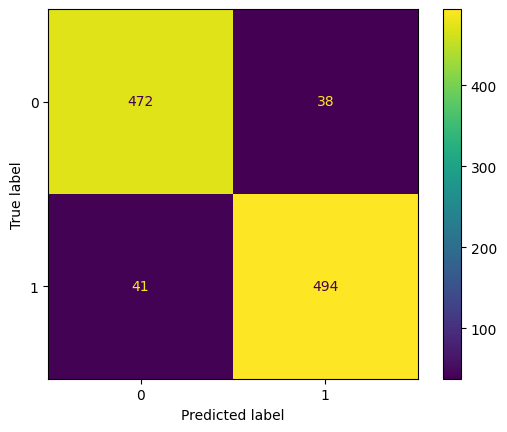

--------- ViT_L16 -----------
tp = 472
fp = 38
fn = 41
tn = 494
Accuracy = 0.9244019138755981
Precision = 0.9254901960784314
Recall = 0.9200779727095516
F1_Score = 0.9227761485826002


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score,ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# الحصول على التوقعات
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

y_test = []
for images, labels in test_ds:
    y_test.extend(labels.numpy())
y_test = np.array(y_test)


# حساب المقاييس
result = accuracy_score(y_test, y_pred)
tp, fp, fn, tn = confusion_matrix(y_test, y_pred).ravel()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print("--------- ViT_L16 -----------")
print("tp =", tp)
print("fp =", fp)
print("fn =", fn)
print("tn =", tn)

Accuracy = (tp + tn) / (tp + tn + fp + fn)
Precision = tp / (tp + fp) if (tp + fp) > 0 else 0
Recall = tp / (tp + fn) if (tp + fn) > 0 else 0
F1_Score = 2 * ((Precision * Recall) / (Precision + Recall)) if (Precision + Recall) > 0 else 0

print("Accuracy =", Accuracy)
print("Precision =", Precision)
print("Recall =", Recall)
print("F1_Score =", F1_Score)

In [ ]:
# ========== إعادة التدريب==========
from tensorflow.keras import layers, Model
from transformers import TFViTModel, ViTConfig
import tensorflow as tf
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

# 1. تعريف النموذج بنفس البنية الأصلية
class ViTLayer(layers.Layer):
    def __init__(self, vit_model, model_name="google/vit-large-patch16-224", **kwargs):
        super().__init__(**kwargs)
        self.vit_model = vit_model
        self.model_name = model_name  # حفظ اسم النموذج للتكوين

    def build(self, input_shape):
        super().build(input_shape)
        self.built = True

    def call(self, inputs):
        # تحويل الصيغة (batch, 224, 224, 3) → (batch, 3, 224, 224)
        inputs = tf.transpose(inputs, perm=[0, 3, 1, 2])
        outputs = self.vit_model(inputs)
        return outputs.last_hidden_state[:, 0, :]  # [CLS] token

    def get_config(self):
        """هذا مهم جداً لحفظ النموذج وإعادة تحميله!"""
        config = super().get_config()
        config.update({
            "model_name": self.model_name,
            # لا نحفظ النموذج نفسه، فقط المعلومات اللازمة لإعادة البناء
        })
        return config

    @classmethod
    def from_config(cls, config):
        """إعادة بناء الطبقة من التكوين المحفوظ"""
        # عند التحميل، نعيد بناء ViT من الصفر
        vit_model = TFViTModel.from_pretrained(config["model_name"])

        # نعيد تطبيق نفس إعدادات التجميد
        for layer in vit_model.layers:
            layer.trainable = False

        # فتح نفس عدد الطبقات
        if "large" in config["model_name"].lower():
            layers_to_unfreeze = 16
        else:
            layers_to_unfreeze = 4

        for i in range(-layers_to_unfreeze, 0):
            try:
                vit_model.vit.encoder.layer[i].trainable = True
            except:
                pass

        return cls(vit_model=vit_model, model_name=config["model_name"])

# 2. بناء النموذج
def build_model():
    print("🔄 تحميل ViT-Large/16 مع تجميد جزئي...")
    MODEL_NAME = "google/vit-large-patch16-224"  # يمكن تغييرها لـ base إذا أردت
    try:
        base_model = TFViTModel.from_pretrained(MODEL_NAME)
    except:
        # البديل إذا فشل التحميل المباشر
        config = ViTConfig.from_pretrained(MODEL_NAME)
        base_model = TFViTModel(config)
        # تجميد جميع الطبقات أولاً
    for layer in base_model.layers:
        layer.trainable = False
        # تحديد عدد الطبقات التي نفتحها
    if "large" in MODEL_NAME.lower():
        layers_to_unfreeze = 16  # لـ ViT-Large
    else:
        layers_to_unfreeze = 4  # لـ ViT-Base

    # فتح آخر 'layers_to_unfreeze' طبقات من الـ Transformer encoder
    print(f"📊 فتح آخر {layers_to_unfreeze} طبقات للتدريب...")
    for i in range(-layers_to_unfreeze, 0):
        try:
            base_model.vit.encoder.layer[i].trainable = True
            print(f"  ✓ فتحت الطبقة {i+25 if 'large' in MODEL_NAME else i+13}")
        except:
            print(f"  ⚠️ لا يمكن فتح الطبقة {i}")

    input_layer = layers.Input(shape=(224, 224, 3), name="input_image")
    vit_layer = ViTLayer(vit_model=base_model,model_name=MODEL_NAME,name="vit_encoder")
    vit_output = vit_layer(input_layer)
    x = layers.BatchNormalization(name="bn1")(vit_output)
    x = layers.Dense(256, activation='relu', name="dense1")(x)
    x = layers.Dropout(0.5, name="dropout1")(x)
    x = layers.Dense(64, activation='relu', name="dense2")(x)
    x = layers.Dropout(0.5, name="dropout2")(x)
    x = layers.Dense(32, activation='relu', name="dense3")(x)
    x = layers.Dropout(0.2, name="dropout3")(x)
    binary_output = layers.Dense(1, activation='sigmoid', name="output")(x)
    model = Model(inputs=input_layer,outputs=binary_output,name="ViT_Ocular_Binary")
    return model

# 3. تحميل النموذج والأوزان
model = build_model()
model.load_weights("/content/drive/MyDrive/wright_model/weights_VITL16_B.weights.h5")

# 4. تجميع النموذج بنفس الإعدادات الأصلية
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-07
    ),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
 )

# 5. إعداد Callbacks
checkpoint_path = "/content/drive/MyDrive/wright_model/weights_VITL16_B.weights.h5"
log_path = "/content/drive/MyDrive/wright_model/history_ViTL16.csv"
callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),

    # 3. Early Stopping
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # 4. ضبط معدل التعلم
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # 5. تسجيل التاريخ
    CSVLogger(
        filename=log_path,
        separator=',',
        append=True
    )
]

# 6. تحميل تاريخ التدريب السابق (إن وجد)
initial_epoch = 0
try:
    import pandas as pd
    log_data = pd.read_csv(log_path)
    initial_epoch = len(log_data)
    print(f"استئناف التدريب من الـ epoch {initial_epoch}")
except:
    print("بدء التدريب من الـ epoch 0")

# التدريب
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=40,
    initial_epoch=initial_epoch,
    callbacks=callbacks,
    verbose=1
)

🔄 تحميل ViT-Large/16 مع تجميد جزئي...


Some layers from the model checkpoint at google/vit-large-patch16-224 were not used when initializing TFViTModel: ['classifier']
- This IS expected if you are initializing TFViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFViTModel were not initialized from the model checkpoint at google/vit-large-patch16-224 and are newly initialized: ['vit/pooler/dense/kernel:0', 'vit/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


📊 فتح آخر 16 طبقات للتدريب...
  ✓ فتحت الطبقة 9
  ✓ فتحت الطبقة 10
  ✓ فتحت الطبقة 11
  ✓ فتحت الطبقة 12
  ✓ فتحت الطبقة 13
  ✓ فتحت الطبقة 14
  ✓ فتحت الطبقة 15
  ✓ فتحت الطبقة 16
  ✓ فتحت الطبقة 17
  ✓ فتحت الطبقة 18
  ✓ فتحت الطبقة 19
  ✓ فتحت الطبقة 20
  ✓ فتحت الطبقة 21
  ✓ فتحت الطبقة 22
  ✓ فتحت الطبقة 23
  ✓ فتحت الطبقة 24
استئناف التدريب من الـ epoch 30
Epoch 31/40
    146/Unknown 232s 1s/step - accuracy: 0.9402 - auc: 0.9857 - loss: 0.1537

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 31: val_accuracy improved from -inf to 0.91774, saving model to /content/drive/MyDrive/wright_model/weights_VITL16_B.weights.h5
146/146 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.9402 - auc: 0.9857 - loss: 0.1537 - val_accuracy: 0.9177 - val_auc: 0.9778 - val_loss: 0.1946 - learning_rate: 1.0000e-04
Epoch 32/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9353 - auc: 0.9831 - loss: 0.1638
Epoch 32: val_accuracy improved from 0.91774 to 0.91945, saving model to /content/drive/MyDrive/wright_model/weights_VITL16_B.weights.h5
146/146 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.9353 - auc: 0.9831 - loss: 0.1638 - val_accuracy: 0.9195 - val_auc: 0.9784 - val_loss: 0.1887 - learning_rate: 1.0000e-04
Epoch 33/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9388 - auc: 0.9832 - loss: 0.1596
Epoch 33: val_accuracy did not improve from 0.91945
146/146 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.9387 - auc: 0.9832 - loss: 0.1596 - val_accuracy: 0.9160 - val_a

37/37 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step


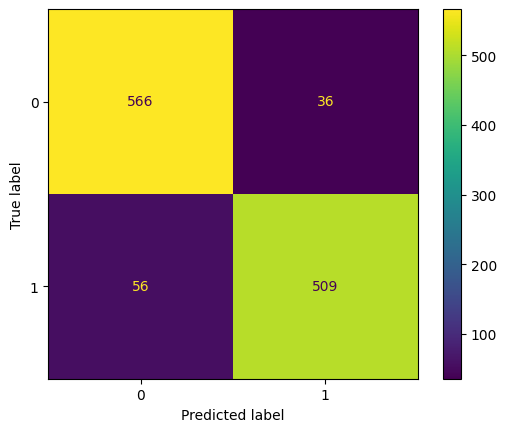

--------- ViT_L16 -----------
tp = 566
fp = 36
fn = 56
tn = 509
Accuracy = 0.921165381319623
Precision = 0.9401993355481728
Recall = 0.909967845659164
F1_Score = 0.9248366013071896


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score,ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# الحصول على التوقعات
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

y_test = []
for images, labels in test_ds:
    y_test.extend(labels.numpy())
y_test = np.array(y_test)


# حساب المقاييس
result = accuracy_score(y_test, y_pred)
tp, fp, fn, tn = confusion_matrix(y_test, y_pred).ravel()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print("--------- ViT_L16 -----------")
print("tp =", tp)
print("fp =", fp)
print("fn =", fn)
print("tn =", tn)

Accuracy = (tp + tn) / (tp + tn + fp + fn)
Precision = tp / (tp + fp) if (tp + fp) > 0 else 0
Recall = tp / (tp + fn) if (tp + fn) > 0 else 0
F1_Score = 2 * ((Precision * Recall) / (Precision + Recall)) if (Precision + Recall) > 0 else 0

print("Accuracy =", Accuracy)
print("Precision =", Precision)
print("Recall =", Recall)
print("F1_Score =", F1_Score)

In [ ]:
import tensorflow as tf
import os
import numpy as np
import json
from pathlib import Path

print("🚀 بدء معالجة البيانات للرأس الأول والثاني...")

# ========== 1. إعدادات المسارات ==========
base_path = '/content/Data_Zain_Enhanced_Uniform'

# مصادر بيانات الرأس الأول
normal_ocular_path = '/content/Data_Zain_Enhanced_Uniform/Normal/Normal_Ocular'  # Normal فقط من Ocular
diabetes_base_path = '/content/Data_Zain_Enhanced_Uniform/diabetes'
others_path = '/content/Data_Zain_Enhanced_Uniform/Others'

# مصادر بيانات الرأس الثاني (ثلاثة فئات ضمن Diabetes)
diabetes_paths = {
    'mild_moderate': '/content/Data_Zain_Enhanced_Uniform/diabetes/mild_moderate',
    'severe': '/content/Data_Zain_Enhanced_Uniform/diabetes/severe'
}

# ========== 2. دالة معالجة الصور لـ ViT (كما هي) ==========
def load_and_preprocess_image_vit(file_path):
    img = tf.io.read_file(file_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0
    return img

# ========== 3. دالة إنشاء TFRecord مع تسمية فئوية ==========
def create_tfrecord_example_categorical(image_path, label, num_classes):
    """إنشاء مثال TFRecord مع تسمية فئوية"""
    image = load_and_preprocess_image_vit(image_path)
    image_bytes = tf.io.serialize_tensor(image).numpy()

    # تحويل التسمية إلى one-hot
    label_one_hot = tf.keras.utils.to_categorical(label, num_classes=num_classes).astype(np.float32).tolist()

    feature = {
        'image': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_bytes])),
        'label': tf.train.Feature(float_list=tf.train.FloatList(value=label_one_hot)),
        'label_raw': tf.train.Feature(int64_list=tf.train.Int64List(value=[label])),
        'image_path': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_path.encode('utf-8')]))
    }
    return tf.train.Example(features=tf.train.Features(feature=feature))

# ========== 3.1 دالة إنشاء TFRecord للتصنيف الثنائي (sigmoid) ==========
def create_tfrecord_example_binary(image_path, label):
    """إنشاء مثال TFRecord مع تسمية ثنائية (0 أو 1)"""
    image = load_and_preprocess_image_vit(image_path)
    image_bytes = tf.io.serialize_tensor(image).numpy()

    feature = {
        'image': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_bytes])),
        'label': tf.train.Feature(float_list=tf.train.FloatList(value=[float(label)])),  # عدد عائم واحد
        'label_raw': tf.train.Feature(int64_list=tf.train.Int64List(value=[label])),
        'image_path': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_path.encode('utf-8')]))
    }
    return tf.train.Example(features=tf.train.Features(feature=feature))

# ========== 4. معالجة الرأس الأول (3 فئات) ==========
print("\n📊 معالجة بيانات الرأس الأول (Normal/Diabetes/Others)...")

# جمع صور Normal_Ocular (1306 صورة فقط)
normal_images = []
if os.path.exists(normal_ocular_path):
    all_normal = [os.path.join(normal_ocular_path, f) for f in os.listdir(normal_ocular_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    np.random.shuffle(all_normal)
    normal_images = all_normal[:1306]  # أخذ أول 1306 فقط
    print(f"  ✓ Normal (Ocular): {len(normal_images)} صورة")

# جمع صور Diabetes (1306 صورة)
diabetes_images = []
for severity in ['mild_moderate', 'severe']:
    folder = diabetes_paths[severity]
    if os.path.exists(folder):
        images = [os.path.join(folder, f) for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        diabetes_images.extend(images)
        print(f"  ✓ {severity}: {len(images)} صورة")

np.random.shuffle(diabetes_images)
diabetes_images = diabetes_images[:1306]  # أخذ 1306 فقط
print(f"  ✓ Diabetes (الإجمالي بعد التقليل): {len(diabetes_images)} صورة")

# جمع صور Others (1306 صورة)
others_images = []
if os.path.exists(others_path):
    all_others = [os.path.join(others_path, f) for f in os.listdir(others_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    np.random.shuffle(all_others)
    others_images = all_others[:1306]  # أخذ 1306 فقط
    print(f"  ✓ Others: {len(others_images)} صورة")

# تجميع بيانات الرأس الأول مع التسميات: Normal=0, Diabetes=1, Others=2
head1_data = [(img, 0) for img in normal_images] + \
             [(img, 1) for img in diabetes_images] + \
             [(img, 2) for img in others_images]

print(f"  📈 إجمالي الرأس الأول: {len(head1_data)} صورة (1306 لكل فئة)")

# خلط وحفظ بيانات الرأس الأول
np.random.shuffle(head1_data)
split_idx = int(len(head1_data) * 0.8)
train_head1 = head1_data[:split_idx]
test_head1 = head1_data[split_idx:]

# حفظ الرأس الأول
head1_path = '/content/drive/MyDrive/Data_Zain/Head1_MultiClass_Data'
os.makedirs(head1_path, exist_ok=True)

# حفظ التدريب
print(f"\n💾 حفظ تدريب الرأس الأول ({len(train_head1)} صورة)...")
with tf.io.TFRecordWriter(f'{head1_path}/train.tfrecord') as writer:
    for i, (img_path, label) in enumerate(train_head1):
        example = create_tfrecord_example_categorical(img_path, label, num_classes=3)
        writer.write(example.SerializeToString())
        if (i+1) % 500 == 0:
            print(f"  ✓ {i+1}/{len(train_head1)}")

# حفظ الاختبار
print(f"💾 حفظ اختبار الرأس الأول ({len(test_head1)} صورة)...")
with tf.io.TFRecordWriter(f'{head1_path}/test.tfrecord') as writer:
    for i, (img_path, label) in enumerate(test_head1):
        example = create_tfrecord_example_categorical(img_path, label, num_classes=3)
        writer.write(example.SerializeToString())

# حفظ إحصائيات الرأس الأول
head1_stats = {
    'classes': ['Normal', 'Diabetes', 'Others'],
    'train_count': len(train_head1),
    'test_count': len(test_head1),
    'total_count': len(head1_data),
    'class_distribution': {
        'Normal': len(normal_images),
        'Diabetes': len(diabetes_images),
        'Others': len(others_images)
    }
}
with open(f'{head1_path}/dataset_stats.json', 'w') as f:
    json.dump(head1_stats, f, indent=4)

print(f"✅ تم حفظ بيانات الرأس الأول في: {head1_path}")

# ========== 5. معالجة الرأس الثاني (تصنيف ثنائي: Mild+Moderate vs Severe) ==========
print("\n📊 معالجة بيانات الرأس الثاني (Mild+Moderate vs Severe)...")

head2_data = []
class_counts = {'mild_moderate': 0, 'severe': 0}

# فئة Mild+Moderate (التسمية 0)
for severity in ['mild_moderate']:
    folder = diabetes_paths[severity]
    if os.path.exists(folder):
        images = [os.path.join(folder, f) for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        np.random.shuffle(images)
        selected_images = images[:653]
        head2_data.extend([(img, 0) for img in selected_images])
        class_counts['mild_moderate'] += len(selected_images)

# فئة Severe (التسمية 1)
folder = diabetes_paths['severe']
if os.path.exists(folder):
    images = [os.path.join(folder, f) for f in os.listdir(folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    np.random.shuffle(images)
    selected_images = images[:653]
    head2_data.extend([(img, 1) for img in selected_images])
    class_counts['severe'] = len(selected_images)

print(f"  📈 إجمالي الرأس الثاني: {len(head2_data)} صورة")

np.random.shuffle(head2_data)
split_idx = int(len(head2_data) * 0.8)
train_head2 = head2_data[:split_idx]
test_head2 = head2_data[split_idx:]

head2_path = '/content/drive/MyDrive/Data_Zain/Head2_DiabetesSeverity_Binary'
os.makedirs(head2_path, exist_ok=True)

# حفظ التدريب للرأس الثاني (باستخدام الدالة الثنائية)
print(f"\n💾 حفظ تدريب الرأس الثاني ({len(train_head2)} صورة)...")
with tf.io.TFRecordWriter(f'{head2_path}/train.tfrecord') as writer:
    for i, (img_path, label) in enumerate(train_head2):
        example = create_tfrecord_example_binary(img_path, label)  # استخدام الدالة الجديدة
        writer.write(example.SerializeToString())

print(f"💾 حفظ اختبار الرأس الثاني ({len(test_head2)} صورة)...")
with tf.io.TFRecordWriter(f'{head2_path}/test.tfrecord') as writer:
    for i, (img_path, label) in enumerate(test_head2):
        example = create_tfrecord_example_binary(img_path, label)  # استخدام الدالة الجديدة
        writer.write(example.SerializeToString())

head2_stats = {
    'classes': ['Mild_Moderate', 'Severe'],
    'train_count': len(train_head2),
    'test_count': len(test_head2),
    'total_count': len(head2_data),
    'class_distribution': class_counts
}
with open(f'{head2_path}/dataset_stats.json', 'w') as f:
    json.dump(head2_stats, f, indent=4)

print(f"✅ تم حفظ بيانات الرأس الثاني في: {head2_path}")

# ========== 6. دالة تحميل TFRecord للرأسين ==========
def parse_head_record(example_proto, num_classes):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([num_classes], tf.float32),
        'label_raw': tf.io.FixedLenFeature([], tf.int64),
        'image_path': tf.io.FixedLenFeature([], tf.string)
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    image = tf.io.parse_tensor(parsed['image'], out_type=tf.float32)
    image = tf.ensure_shape(image, [224, 224, 3])
    label = parsed['label']
    label_raw = parsed['label_raw']
    return image, label

# ========== 6.1 دالة تحميل TFRecord للتصنيف الثنائي (sigmoid) ==========
def parse_head_record_binary(example_proto):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([1], tf.float32),  # عدد واحد فقط
        'label_raw': tf.io.FixedLenFeature([], tf.int64),
        'image_path': tf.io.FixedLenFeature([], tf.string)
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    image = tf.io.parse_tensor(parsed['image'], out_type=tf.float32)
    image = tf.ensure_shape(image, [224, 224, 3])
    label = parsed['label'][0]  # استخراج القيمة العائمة الواحدة
    return image, label

# اختبار سريع
print("\n🧪 اختبار تحميل البيانات...")

# اختبار الرأس الأول
dataset1 = tf.data.TFRecordDataset([f'{head1_path}/test.tfrecord'])
dataset1 = dataset1.map(lambda x: parse_head_record(x, 3))
dataset1 = dataset1.batch(2).take(1)
for images, labels in dataset1:
    print(f"\n✅ الرأس الأول:")
    print(f"  - شكل الصور: {images.shape}")
    print(f"  - شكل التسميات: {labels.shape} (one-hot)")
    print(f"  - مثال تسميات: {labels.numpy()[0]}")

# اختبار الرأس الثاني (binary)
dataset2 = tf.data.TFRecordDataset([f'{head2_path}/test.tfrecord'])
dataset2 = dataset2.map(parse_head_record_binary)  # استخدام الدالة الثنائية
dataset2 = dataset2.batch(2).take(1)
for images, labels in dataset2:
    print(f"\n✅ الرأس الثاني (binary):")
    print(f"  - شكل الصور: {images.shape}")
    print(f"  - شكل التسميات: {labels.shape} (binary: 0 أو 1)")
    print(f"  - مثال تسميات: {labels.numpy()}")

🚀 بدء معالجة البيانات للرأس الأول والثاني...

📊 معالجة بيانات الرأس الأول (Normal/Diabetes/Others)...
  ✓ Normal (Ocular): 1306 صورة
  ✓ mild_moderate: 653 صورة
  ✓ severe: 653 صورة
  ✓ Diabetes (الإجمالي بعد التقليل): 1306 صورة
  ✓ Others: 1306 صورة
  📈 إجمالي الرأس الأول: 3918 صورة (1306 لكل فئة)

💾 حفظ تدريب الرأس الأول (3134 صورة)...
  ✓ 500/3134
  ✓ 1000/3134
  ✓ 1500/3134
  ✓ 2000/3134
  ✓ 2500/3134
  ✓ 3000/3134
💾 حفظ اختبار الرأس الأول (784 صورة)...
✅ تم حفظ بيانات الرأس الأول في: /content/drive/MyDrive/Data_Zain/Head1_MultiClass_Data

📊 معالجة بيانات الرأس الثاني (Mild+Moderate vs Severe)...
  📈 إجمالي الرأس الثاني: 1306 صورة

💾 حفظ تدريب الرأس الثاني (1044 صورة)...
💾 حفظ اختبار الرأس الثاني (262 صورة)...
✅ تم حفظ بيانات الرأس الثاني في: /content/drive/MyDrive/Data_Zain/Head2_DiabetesSeverity_Binary

🧪 اختبار تحميل البيانات...

✅ الرأس الأول:
  - شكل الصور: (2, 224, 224, 3)
  - شكل التسميات: (2, 3) (one-hot)
  - مثال تسميات: [1. 0. 0.]

✅ الرأس الثاني (binary):
  - شكل الصور: 

In [ ]:
import shutil
import os

def compress_folder(folder_path, output_filename='compressed_folder'):

    try:
        # التأكد من وجود المجلد
        if not os.path.exists(folder_path):
            print(f"❌ المجلد '{folder_path}' غير موجود")
            return None

        # إنشاء اسم ملف الزيب
        zip_filename = f"{output_filename}.zip"

        # ضغط المجلد
        shutil.make_archive(output_filename, 'zip', folder_path)

        print(f"✅ تم ضغط '{folder_path}' إلى '{zip_filename}'")
        print(f"📁 حجم الملف: {os.path.getsize(zip_filename) / (1024*1024):.2f} MB")

        return zip_filename

    except Exception as e:
        print(f"❌ حدث خطأ: {e}")
        return None

# مثال للاستخدام:
if __name__ == "__main__":
    # ضغط مجلد محدد
    compressed_file = compress_folder('/content/drive/MyDrive/wright_model', '/content/wright_model')


✅ تم ضغط '/content/drive/MyDrive/wright_model' إلى '/content/wright_model.zip'
📁 حجم الملف: 2.97 MB


تم حفظ مخطط النموذج في ملف 'multi_task_model.png'


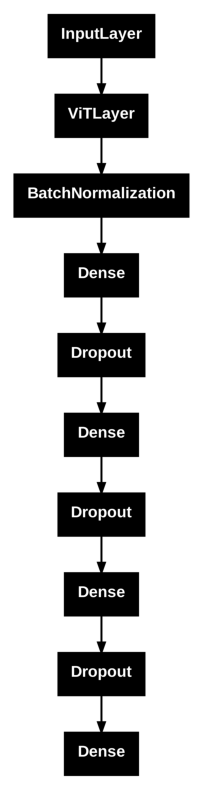

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='model_binary.png',
    show_shapes=False,
    show_layer_names=False,
    rankdir='TB',
    dpi=500,
)
print("تم حفظ مخطط النموذج في ملف 'multi_task_model.png'")
# تحميل وعرض الصورة
img = mpimg.imread('model_binary.png')
plt.figure(figsize=(15, 10))  # تحديد حجم الشكل
plt.imshow(img)
plt.axis('off')  # إخفاء محاور الصورة
plt.show()